# Project Description: OSCC Recurrence Prediction

## 1. Project Background
This study addresses the challenge of predicting recurrence in Oral Squamous Cell Carcinoma (OSCC). Using a dataset of 219 cases, we evaluate sociodemographic and clinicopathological parameters to build a robust classification model.

## 2. Methodology
*   **Data Processing:** `OneHotEncoding` for categorical variables and `StandardScaler` for numerical data.
*   **Modeling:** Comparison between Logistic Regression, Random Forest, and XGBoost.
*   **Clinical Tuning:** Implementation of threshold moving (0.35) and class weighting to handle minority class importance.
*   **Explainability:** SHAP integration to explain feature impact on individual patient predictions.

## 3. Technology Stack
*   **Languages:** Python
*   **Data Science:** Pandas, NumPy, Scikit-learn
*   **Boosting:** XGBoost
*   **Interpretability:** SHAP
*   **Visualization:** Matplotlib, Seaborn
*   **Deployment:** Streamlit

##Study title: A Machine Learning Predictive Model for Oral Squamous Cell Carcinoma (OSCC) Recurrence.

Aim: To develop a ML-based predictive model for OSCC recurrence and recurrence interval using sociodemographic data, clinicopathological features, and IHC expression of EGFR, p53, Ki-67.


Objectives:

i.               To identify the sociodemographic and clinicopathological factors that are associated with OSCC recurrence.

ii.              To investigate the association between the expression of EGFR, p53, and Ki-67 and OSCC recurrence.

iii.            To develop a machine learning model that best predicts OSCC recurrence and recurrence-interval.



Current Excel sheet structure



Total of 219 cases



1. Risk factors for recurrence (Green)

These include all the sociodemographic and clinicopathological parameters.



2. Outcome

i)Recurrence (Yellow)

This is the main outcome variable for the machine learning model. Recurrence includes local recurrence (LR) and locoregional recurrence (LRR).

Total cases: 35


>  These bottom two we dont use yet, we just want to focus on building a solid ML model that can predice recurrence

ii) Early / Late recurrence (Pink)

This classifies the recurrence cases by when they occurred.

Early recurrence: ≤ 24 months

Late recurrence: ≥ 25 months



iii)Relapse (Grey)

Broader category including LR, LRR, and second primary tumour (SPT).

Total cases: 48

If you installed those packages into the same Python environment that your new project uses, they will still work in the new project. If the new project uses a different virtual environment, they will not be available until you install them there too. For notebooks, the selected kernel must point to that same environment.

##Import

In [1]:
import pandas as pd
string = "ML TEST DATASET3.xlsx"
df = pd.read_excel(string)
df.head()


,STUDY ID,AGE,SEX,ETHNICITY,ALCOHOL,SMOKER,BETEL NUT CHEWER,COMORBID,TUMOUR SIZE(pT),NODAL INVOLVEMENT,...,TUMOUR GRADING,PNI,LVI,PRIMARY TUMOUR SITE,TYPE OF PRIMARY SURGICAL INTERVENTION,POST ADJUVANT THERAPY,"RECURRENCE (LR, LRR)",EARLY RECURRENCE,LATE RECURRENCE,"RELAPSE (LR, LRR, SPT)"
0,P001,71,MALE,INDIAN,YES,NO,NO,YES,2,NO,...,MODERATE,NO,YES,Tongue,Wide excision with neck dissection,NO,NO,NO,NO,NO
1,P004,61,FEMALE,MALAY,NO,NO,YES,NO,2,NO,...,MODERATE,NO,NO,Buccal mucosa,Wide excision with neck dissection,NO,YES,YES,NO,YES
2,P005,66,MALE,INDIAN,NO,NO,NO,YES,1,ND,...,WELL,NO,NO,Tongue,Wide excision only,NO,NO,NO,NO,NO
3,P008,49,MALE,MALAY,NO,YES,NO,NO,2,NO,...,WELL,NO,NO,Tongue,Wide excision with neck dissection,RADIOTHERAPY,NO,NO,NO,NO
4,P009,60,FEMALE,INDIAN,NO,NO,YES,YES,1,ND,...,WELL,NO,NO,Buccal mucosa,Wide excision only,NO,NO,NO,NO,YES


##Data Cleaning and Quality Check


Columns to drop:

STUDY ID -> Irrelevant to the model

EARLY AND LATE RECURRENCE & RELAPSE -> Not used for now

> NOTE: For a classification model, you should drop all 'TIME TO...' columns from your features ($X$$X$). These columns are only useful for a separate Survival Analysis (Regression) later on to predict when it might happen for those who already have it.
Or else the model will learn to cheat, and see which row 0 dia terus predict as no recurrence

Columns that have to adjust to num / special handling:

*   None so far





In [2]:
drop = ['STUDY ID','EARLY RECURRENCE','LATE RECURRENCE','RELAPSE (LR, LRR, SPT)']
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()
df=df.drop(columns = drop)

In [3]:
print(f"Missing values:\n{df.isnull().sum()}")

print(f"\nDistribution of numerical variables:\n{df.describe()}")

print(f"\nThe target variable distribution is as follows: {df['RECURRENCE (LR, LRR)'].value_counts()}")

Missing values:
AGE                                       0
SEX                                       0
ETHNICITY                                 0
ALCOHOL                                   0
SMOKER                                    0
BETEL NUT CHEWER                          0
COMORBID                                  0
TUMOUR SIZE(pT)                           0
NODAL INVOLVEMENT                         0
ENE                                       0
p(N)                                      0
pTNM STAGING                              0
VARIANT                                   0
DOI(mm)                                   0
TUMOUR DIMENSION(mm)                      0
wPOI                                      0
LHR                                       0
BONE INVASION                             0
BONE INVASION (TYPE)                      0
SURGICAL MARGIN                           0
DYSPLASIA AT SURGICAL MARGIN              0
DYSPLASIA AT SURGICAL MARGIN (GRADING)    0
TUMOUR GRADING  

In [4]:
'''# Convert 'NIL' to NaN and then fill NaN with mean for specified columns
columns_to_process = ['TIME TO LAST VISIT (MONTHS)', 'TIME TO DEATH (MONTHS)']

for col in columns_to_process:
    # Convert to numeric, coercing errors (NIL will become NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    df[col] = df[col].fillna(df[col].mean())'''

"# Convert 'NIL' to NaN and then fill NaN with mean for specified columns\ncolumns_to_process = ['TIME TO LAST VISIT (MONTHS)', 'TIME TO DEATH (MONTHS)']\n\nfor col in columns_to_process:\n    # Convert to numeric, coercing errors (NIL will become NaN)\n    df[col] = pd.to_numeric(df[col], errors='coerce')\n    # Fill NaN values with the mean of the column\n    df[col] = df[col].fillna(df[col].mean())"

> No missing values and distribution of numerical variables are good, only TUMOUR DIMENSION has a few outliers. Although target variable is very class imbalanced. This will be addressed in the model training section

##EDA

C:\Users\mdani\AppData\Local\Temp\ipykernel_2056\2458194063.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_encoded.select_dtypes(include=['object']).columns


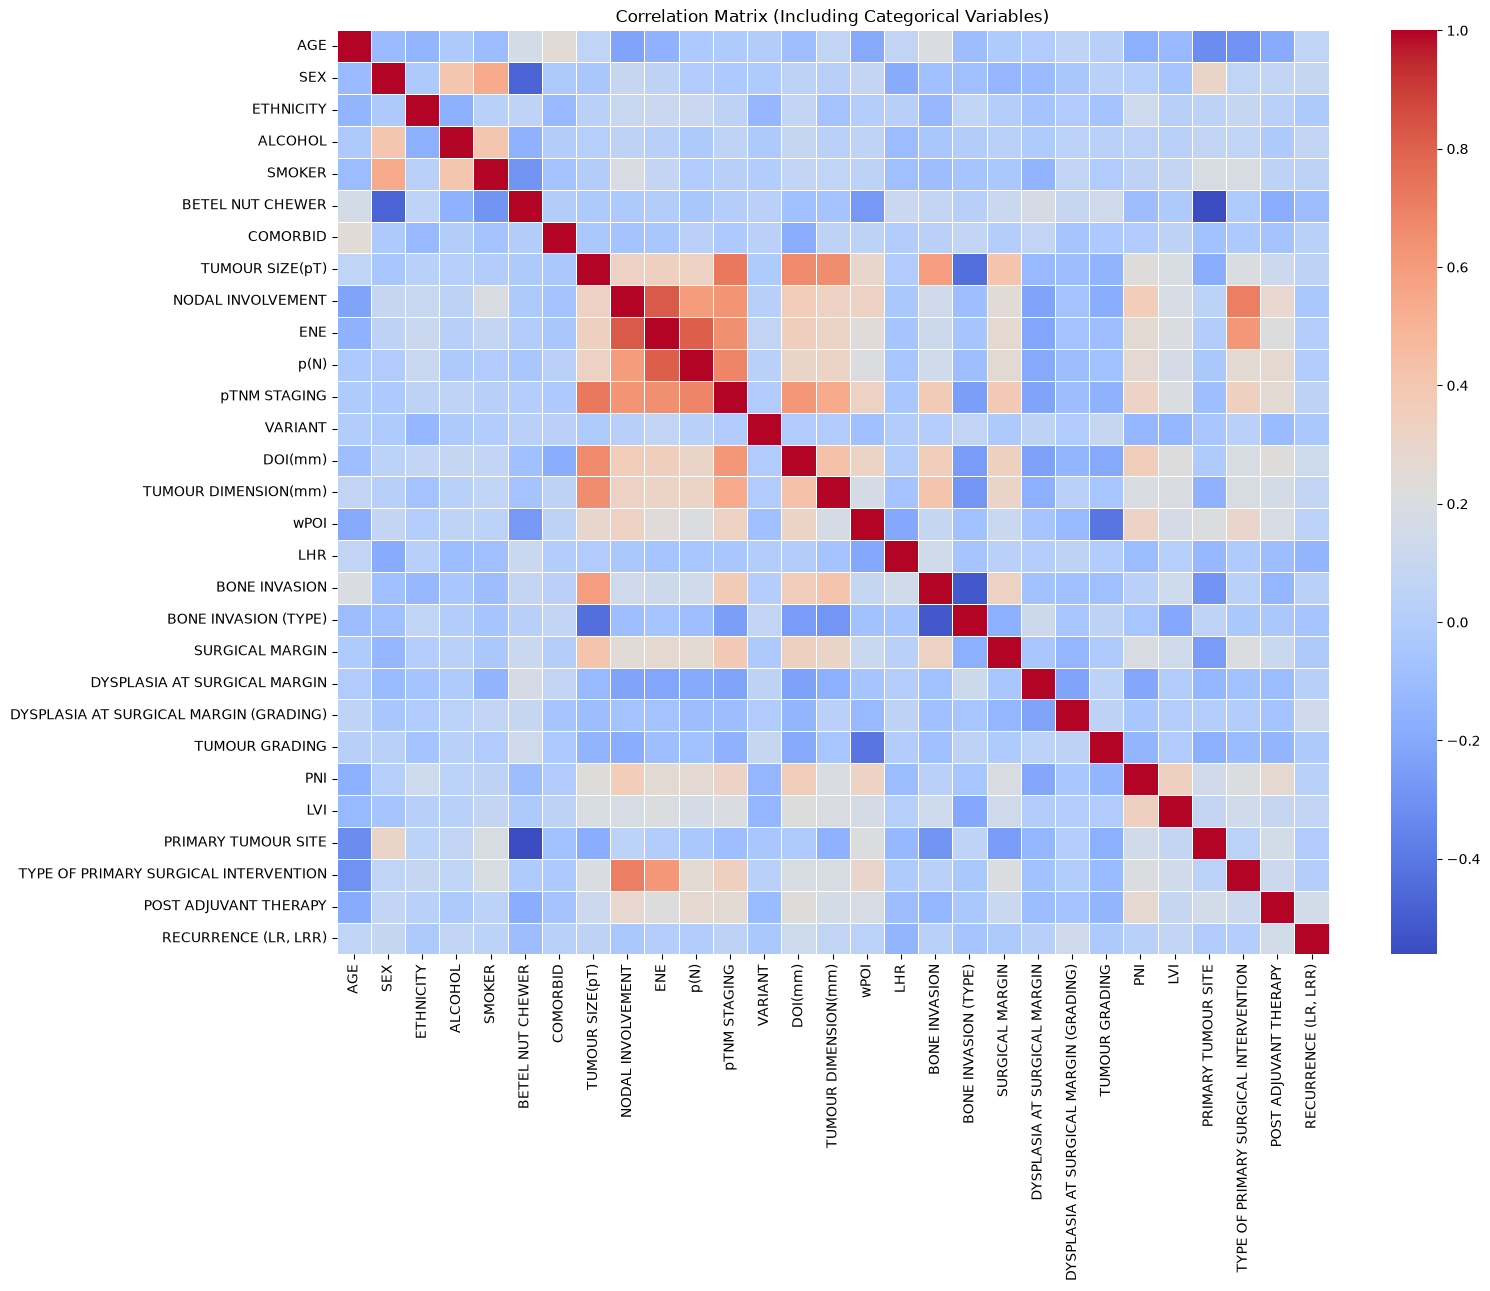

In [5]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy for analysis so we don't mess up the original df
df_encoded = df.copy()

# Identifying categorical columns (object type)
cat_cols = df_encoded.select_dtypes(include=['object']).columns

# Using Label Encoding for a simpler correlation matrix
# (Alternatively, you could use pd.get_dummies for one-hot encoding)
le = LabelEncoder()
for col in cat_cols:
    # We convert to string first to handle any mixed types just in case
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Calculate correlation on the encoded dataframe
full_corr = df_encoded.corr()

# Create a larger heatmap for readability
plt.figure(figsize=(16, 12))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Including Categorical Variables)')
plt.show()

> From the Correlation Matrix, On the surface, no variables have an immediate obivous correlation with recurrence of patients.

###Demographic EDA

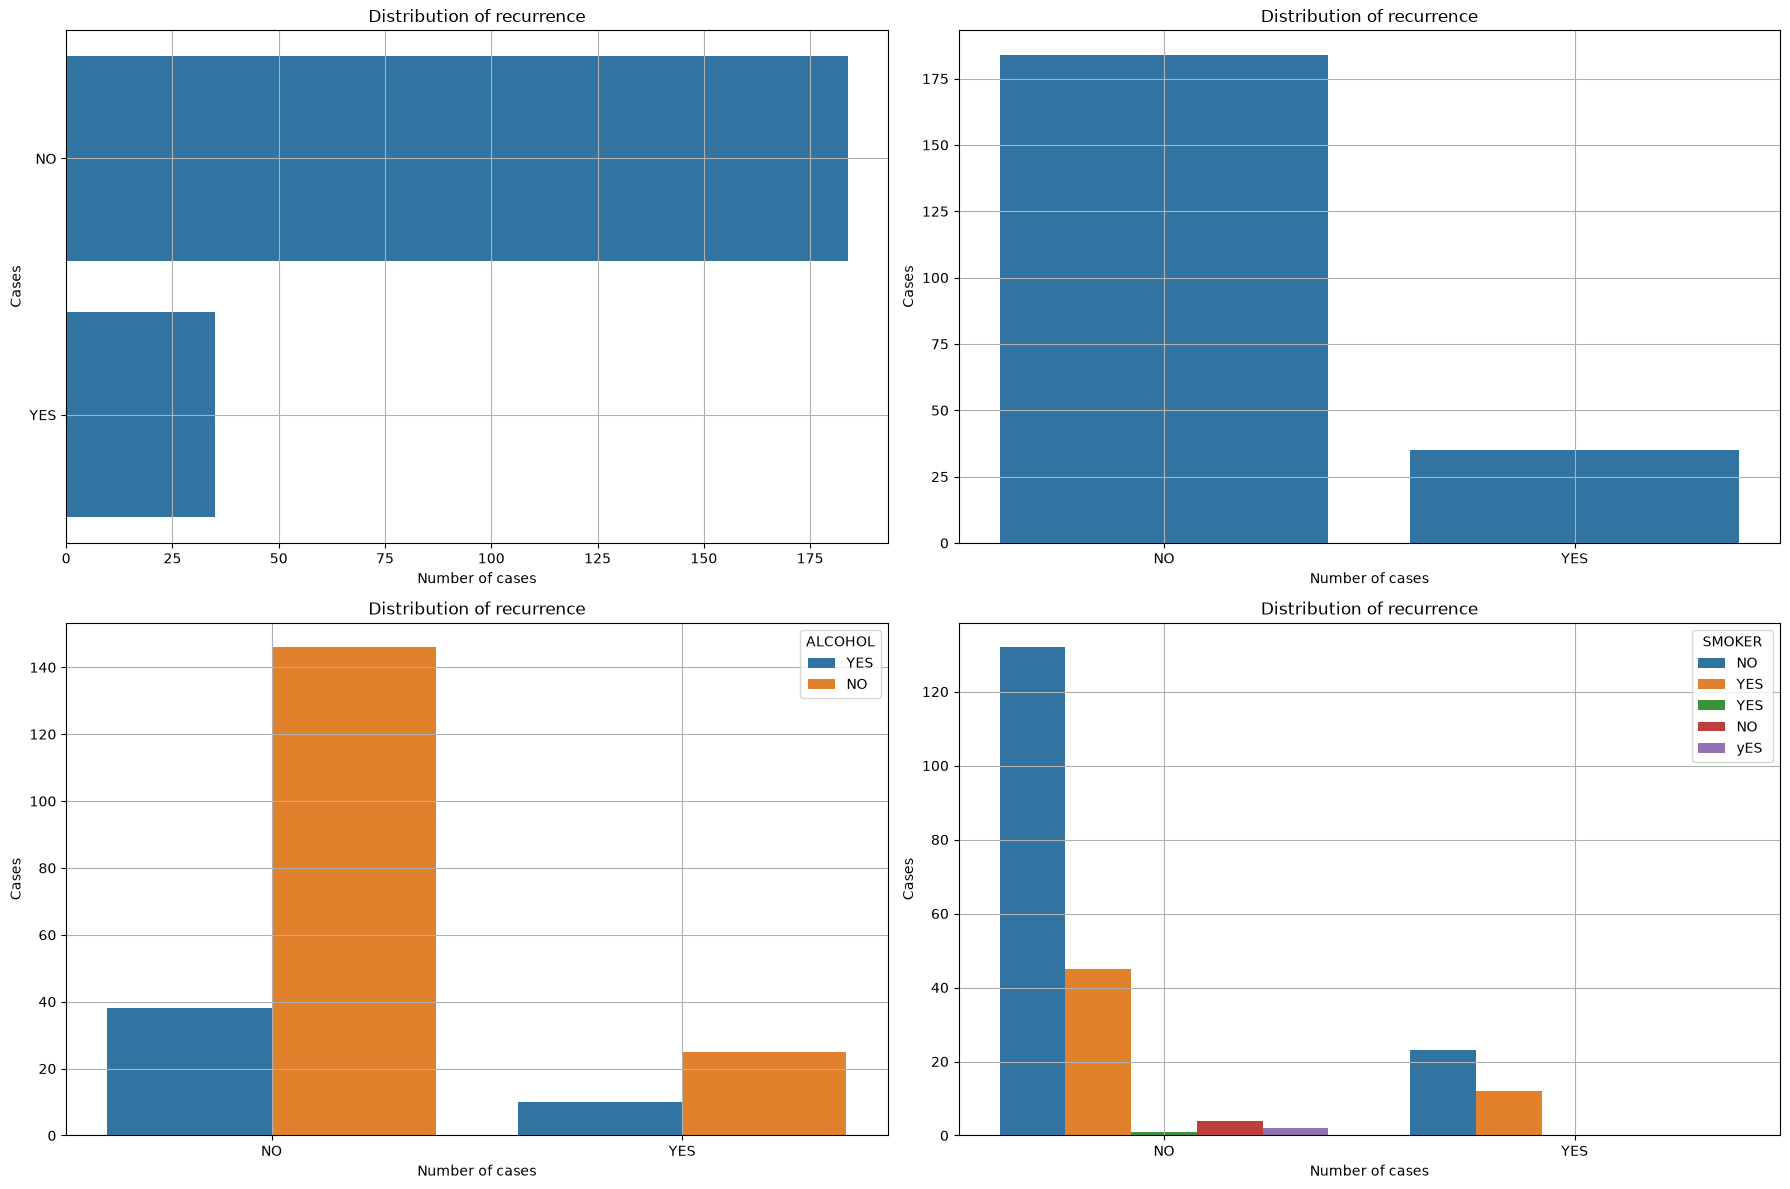

In [6]:

plt.figure(figsize=(18,12))

plt.subplot(2, 2, 1)
sns.countplot(df['RECURRENCE (LR, LRR)'])

plt.title('Distribution of recurrence')
plt.xlabel('Number of cases')
plt.ylabel('Cases')
plt.grid(True)




plt.subplot(2, 2, 2)
sns.countplot(df,x=df['RECURRENCE (LR, LRR)'])#,hue=df['EARLY RECURRENCE'])

plt.title('Distribution of recurrence')
plt.xlabel('Number of cases')
plt.ylabel('Cases')
plt.tight_layout()
plt.grid(True)



plt.subplot(2, 2, 3)
sns.countplot(df,x=df['RECURRENCE (LR, LRR)'],hue=df['ALCOHOL'])

plt.title('Distribution of recurrence')
plt.xlabel('Number of cases')
plt.ylabel('Cases')
plt.tight_layout()
plt.grid(True)



plt.subplot(2, 2, 4)
sns.countplot(df,x=df['RECURRENCE (LR, LRR)'],hue=df['SMOKER'])

plt.title('Distribution of recurrence')
plt.xlabel('Number of cases')
plt.ylabel('Cases')
plt.tight_layout()
plt.grid(True)

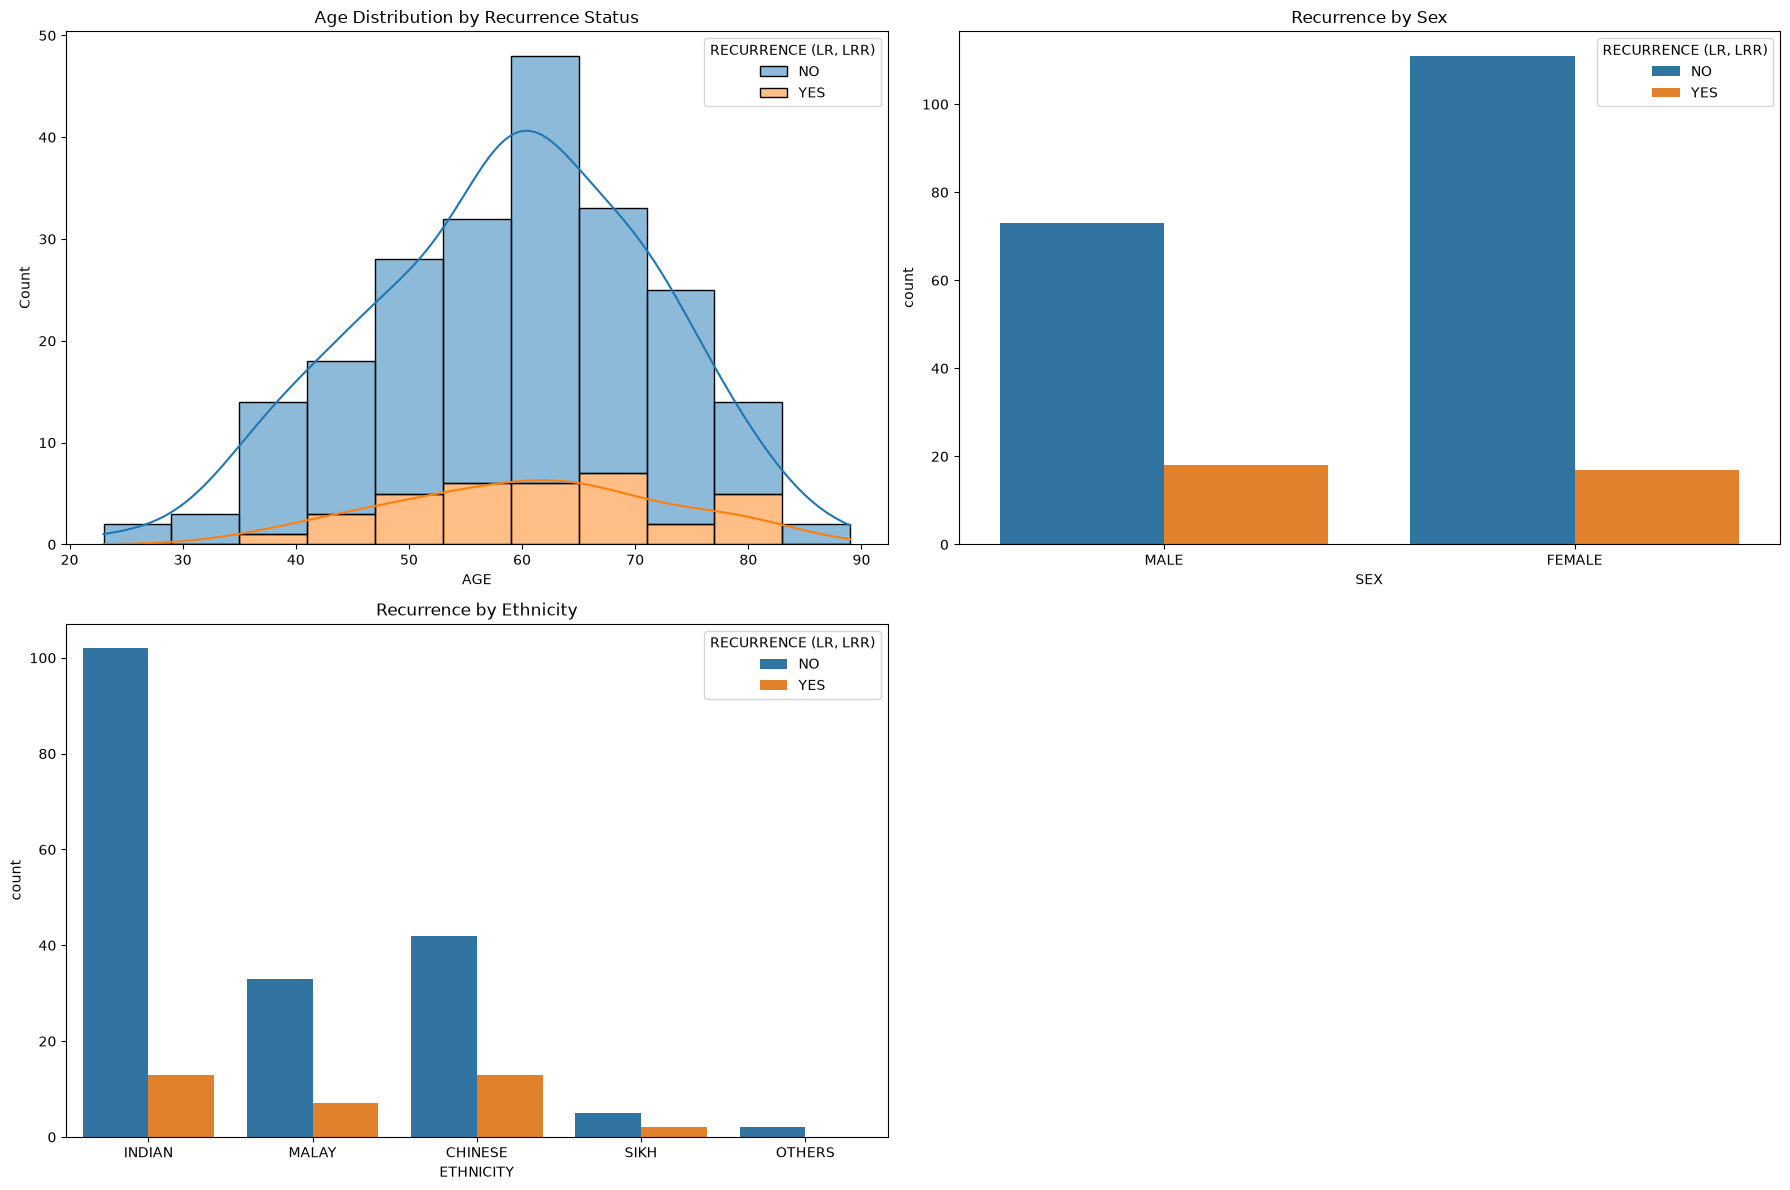

In [7]:
plt.figure(figsize=(18, 12))

# 1. Age vs Recurrence
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='AGE', hue='RECURRENCE (LR, LRR)', multiple='stack', kde=True)
plt.title('Age Distribution by Recurrence Status')

# 2. Sex vs Recurrence
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='SEX', hue='RECURRENCE (LR, LRR)')
plt.title('Recurrence by Sex')

# 3. Ethnicity vs Recurrence
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='ETHNICITY', hue='RECURRENCE (LR, LRR)')
plt.title('Recurrence by Ethnicity')

plt.tight_layout()
plt.show()

##Data Preprocessing

First we use column transformer to prepare the  preprocessors and pass in relevant columns

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

#declare numerical and categorical columns to process and remove the target variable (shouldnt be processed)
cat = df.select_dtypes(exclude=np.number).columns.tolist()
num = df.select_dtypes(include=np.number).columns.tolist()
cat.remove('RECURRENCE (LR, LRR)')

preprocessor = ColumnTransformer(
    transformers=[
        ('nums',StandardScaler(),num),
        ('cols',OneHotEncoder(handle_unknown='ignore'),cat)
    ],
    remainder='passthrough'
)
#see the categorical and numerical columns
print(cat)
print(num)

['SEX', 'ETHNICITY', 'ALCOHOL', 'SMOKER', 'BETEL NUT CHEWER', 'COMORBID', 'NODAL INVOLVEMENT', 'ENE', 'p(N)', 'pTNM STAGING', 'VARIANT', 'DOI(mm)', 'wPOI', 'LHR', 'BONE INVASION', 'BONE INVASION (TYPE)', 'SURGICAL MARGIN', 'DYSPLASIA AT SURGICAL MARGIN', 'DYSPLASIA AT SURGICAL MARGIN (GRADING)', 'TUMOUR GRADING', 'PNI', 'LVI', 'PRIMARY TUMOUR SITE', 'TYPE OF PRIMARY SURGICAL INTERVENTION', 'POST ADJUVANT THERAPY']
['AGE', 'TUMOUR SIZE(pT)', 'TUMOUR DIMENSION(mm)']


Then we declare target variable as Y and features variable as X and only preprocess (fit it) the X columns

In [9]:
#tadi declare numerical and categorical, here we declare target variable and the rest of the variable
target=['RECURRENCE (LR, LRR)']

X=df.copy()
X=X.drop(columns = target)
Y=df[target]

# Convert all categorical columns to string type to avoid TypeError in OneHotEncoder, this handles the column p(N)
for col in cat:
    X[col] = X[col].astype(str)

#then we fit (transform)
processed_data=preprocessor.fit_transform(X)

Split the data into training portion and testing portion

In [10]:
# Perform train-test split on the preprocessed data
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(processed_data, Y, train_size=0.8, random_state=42)

# Convert Y_train and Y_test to numerical format (0 and 1) globally
# XGBoost and other models often expect integer labels starting from 0.
Y_train = Y_train.replace({'NO': 0, 'YES': 1}).astype(int)
Y_test = Y_test.replace({'NO': 0, 'YES': 1}).astype(int)

# Display the shapes of the resulting sets to confirm the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (175, 129)
Shape of X_test: (44, 129)
Shape of Y_train: (175, 1)
Shape of Y_test: (44, 1)


After `ColumnTransformer` processing, we can extract the feature names which is an array, then we create a pandas dataframe by:


Feature names = the headers / columns names and the X train and X test which is the data as the data la, so we will train the models using this instead of the biasa. so u can actually train models using a df wow

In [11]:
feature_names = preprocessor.get_feature_names_out()

# 2. Rebuild clean Pandas DataFrames with the correct column names
# X_train and X_test are already numpy arrays from the preprocessor.fit_transform(X) and subsequent train_test_split.
# Convert sparse arrays to dense arrays before creating DataFrames
X_train_df = pd.DataFrame(X_train.toarray(), columns=feature_names, index=range(X_train.shape[0]))
X_test_df = pd.DataFrame(X_test.toarray(), columns=feature_names, index=range(X_test.shape[0]))

# Check your new dataframe columns to ensure they look right
print("New Feature Names:\n", X_train_df.columns.tolist())
print("\nShape of X_train_df:", X_train_df.shape)
print("Shape of X_test_df:", X_test_df.shape)

New Feature Names:
 ['nums__AGE', 'nums__TUMOUR SIZE(pT)', 'nums__TUMOUR DIMENSION(mm)', 'cols__SEX_FEMALE', 'cols__SEX_MALE', 'cols__ETHNICITY_CHINESE', 'cols__ETHNICITY_INDIAN', 'cols__ETHNICITY_MALAY', 'cols__ETHNICITY_OTHERS', 'cols__ETHNICITY_SIKH', 'cols__ALCOHOL_NO', 'cols__ALCOHOL_YES', 'cols__SMOKER_NO', 'cols__SMOKER_NO ', 'cols__SMOKER_YES', 'cols__SMOKER_YES ', 'cols__SMOKER_yES', 'cols__BETEL NUT CHEWER_NO', 'cols__BETEL NUT CHEWER_YES', 'cols__BETEL NUT CHEWER_YES ', 'cols__BETEL NUT CHEWER_yES', 'cols__COMORBID_NO', 'cols__COMORBID_YES', 'cols__NODAL INVOLVEMENT_ND', 'cols__NODAL INVOLVEMENT_ND ', 'cols__NODAL INVOLVEMENT_NO', 'cols__NODAL INVOLVEMENT_NO ', 'cols__NODAL INVOLVEMENT_YES', 'cols__NODAL INVOLVEMENT_YES ', 'cols__ENE_ND', 'cols__ENE_NO', 'cols__ENE_YES', 'cols__p(N)_0', 'cols__p(N)_1', 'cols__p(N)_2a', 'cols__p(N)_2b', 'cols__p(N)_2c', 'cols__p(N)_3a', 'cols__p(N)_3b', 'cols__pTNM STAGING_1', 'cols__pTNM STAGING_I', 'cols__pTNM STAGING_I ', 'cols__pTNM STAGI

##Training the classification model (first run)

Models suitalbe for a small dataset with class imbalance in the target variable


*   XGBoost (Extreme Gradient Boosting): This is usually the king of tabular data.
It handles non-linear relationships well, deals with missing data natively, and most importantly, it has a built-in parameter (scale_pos_weight) specifically designed to penalize the model heavily if it gets your minority class (the 35 recurrences) wrong.
*   Random Forest: Another powerful tree-based model. It is very robust to overfitting and handles clinical data beautifully. You can use a class_weight='balanced' parameter to help with the 35 vs 165 imbalance.
*   Logistic Regression: The perfect, interpretable "baseline" to see if complex models like XGBoost actually add any real value over a simple equation.



-Gemini 3.5 Pro








###LOGISTIC REGRESSION

The LogisticRegression model expects it to be a 1D array. Fix this by reshaping Y_train using .values.ravel() before fitting the model, which will convert it to the correct 1D format.


In [12]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(X_train_df, Y_train.values.ravel())

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#then we create a class helper which we will just call this for all other models we trained
#inside this class helper, kalau nak performance for training set, X_train and Y_train la, kalau nak performance for testing set, letak la test
def class_helper(X_train,X_test,Y_train,Y_test,model):
    #declare all the variables
    predictions=model.predict(X_train)
    training_acc=accuracy_score(Y_train,predictions)
    training_confm=confusion_matrix(Y_train,predictions)
    training_report=pd.DataFrame(classification_report(Y_train,predictions,output_dict=True))

    predictions=model.predict(X_test)
    testing_acc=accuracy_score(Y_test,predictions)
    testing_confm=confusion_matrix(Y_test,predictions)
    testing_report=pd.DataFrame(classification_report(Y_test,predictions,output_dict=True))
    #output it
    print("Training Accuracy of model is: " + str(training_acc))
    print("\n The training metrics of performance for the model is: \n" + str(training_report))
    print("\n And the confusion matrix is as follows: \n" + str(training_confm))
    print("\n----------------------------------------------")
    print("\n Testing Accuracy of model is: " + str(testing_acc))
    print("\n The testing metrics of performance for the model is: \n" + str(testing_report))
    print("\n And the confusion matrix is as follows: \n" + str(testing_confm))

c:\Downloads\vscode\Codings\OralCancerRelapseClassification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


In [13]:
class_helper(X_train_df,X_test_df,Y_train,Y_test,LR)

Training Accuracy of model is: 0.88

 The training metrics of performance for the model is: 
                    0          1  accuracy   macro avg  weighted avg
precision    0.875740   1.000000      0.88    0.937870      0.894911
recall       1.000000   0.222222      0.88    0.611111      0.880000
f1-score     0.933754   0.363636      0.88    0.648695      0.845793
support    148.000000  27.000000      0.88  175.000000    175.000000

 And the confusion matrix is as follows: 
[[148   0]
 [ 21   6]]

----------------------------------------------

 Testing Accuracy of model is: 0.7954545454545454

 The testing metrics of performance for the model is: 
                   0    1  accuracy  macro avg  weighted avg
precision   0.813953  0.0  0.795455   0.406977      0.665962
recall      0.972222  0.0  0.795455   0.486111      0.795455
f1-score    0.886076  0.0  0.795455   0.443038      0.724971
support    36.000000  8.0  0.795455  44.000000     44.000000

 And the confusion matrix is as fol

###RF AND XGB

In [14]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ==========================================
# 1. Random Forest with Class Weights
# ==========================================
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_df, Y_train.values.ravel())

print("--- Random Forest Performance ---")
class_helper(X_train_df, X_test_df, Y_train, Y_test, rf_model)


# ==========================================
# 2. XGBoost with Class Weights
# ==========================================

# Calculate scale_pos_weight: (Number of Negative Cases) / (Number of Positive Cases)
neg_cases = (Y_train == 0).sum().values[0]
pos_cases = (Y_train == 1).sum().values[0]
scale_weight = neg_cases / pos_cases if pos_cases > 0 else 1 # Avoid division by zero if no positive cases

# Initialize XGBoost with the calculated weight
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
# Pass the raw NumPy matrix (.values) instead of the DataFrame to bypass the Pandas check
xgb_model.fit(X_train_df.values, Y_train.values.ravel()) # Use Y_train here

print("\n--- XGBoost Performance ---")
class_helper(X_train_df, X_test_df, Y_train, Y_test, xgb_model) # Use Y_train and Y_test here

--- Random Forest Performance ---
Training Accuracy of model is: 1.0

 The training metrics of performance for the model is: 
               0     1  accuracy  macro avg  weighted avg
precision    1.0   1.0       1.0        1.0           1.0
recall       1.0   1.0       1.0        1.0           1.0
f1-score     1.0   1.0       1.0        1.0           1.0
support    148.0  27.0       1.0      175.0         175.0

 And the confusion matrix is as follows: 
[[148   0]
 [  0  27]]

----------------------------------------------

 Testing Accuracy of model is: 0.8181818181818182

 The testing metrics of performance for the model is: 
                   0    1  accuracy  macro avg  weighted avg
precision   0.818182  0.0  0.818182   0.409091      0.669421
recall      1.000000  0.0  0.818182   0.500000      0.818182
f1-score    0.900000  0.0  0.818182   0.450000      0.736364
support    36.000000  8.0  0.818182  44.000000     44.000000

 And the confusion matrix is as follows: 
[[36  0]
 [ 8  

c:\Downloads\vscode\Codings\OralCancerRelapseClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Downloads\vscode\Codings\OralCancerRelapseClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Downloads\vscode\Codings\OralCancerRelapseClassification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 


--- XGBoost Performance ---
Training Accuracy of model is: 1.0

 The training metrics of performance for the model is: 
               0     1  accuracy  macro avg  weighted avg
precision    1.0   1.0       1.0        1.0           1.0
recall       1.0   1.0       1.0        1.0           1.0
f1-score     1.0   1.0       1.0        1.0           1.0
support    148.0  27.0       1.0      175.0         175.0

 And the confusion matrix is as follows: 
[[148   0]
 [  0  27]]

----------------------------------------------

 Testing Accuracy of model is: 0.8181818181818182

 The testing metrics of performance for the model is: 
                   0         1  accuracy  macro avg  weighted avg
precision   0.850000  0.500000  0.818182   0.675000      0.786364
recall      0.944444  0.250000  0.818182   0.597222      0.818182
f1-score    0.894737  0.333333  0.818182   0.614035      0.792663
support    36.000000  8.000000  0.818182  44.000000     44.000000

 And the confusion matrix is as follo

> As we can see the performance of all 3 models are very bad. The model is very overfit and memorised the pattern in the data by just predicting all NO and getting a decent accuracy instead of properly learning the patterns behind the data

##Second run of training the model

A few steps to fix the model can be to:

1. Constrain the Models (Hyperparameter Tuning)
Drastically simplify the tree models so they are forced to find global patterns rather than memorizing individual rows. Achieved by limiting how deep the trees can grow.

2. Shift the Decision Threshold (Crucial for Medicine)
By default, .predict() flags a patient as "YES" only if the model is >50% confident. In a clinical setting predicting cancer recurrence, a 50% threshold is way too high. If a model is even 25% or 30% confident that a high-risk patient's cancer will return (based on high Ki-67 or p53), a doctor would want to know, use .predict_proba() and manually lower the threshold.


So we adjust the two by doing hyperparameter tuning to adjust the model

In [15]:
# The updated, balanced, and  LR model
LR = LogisticRegression(
    class_weight='balanced',  # Forces the model to care about Recurrence
    penalty='l1',             # Performs feature selection
    C=0.5,                    # Adds strong regularization to prevent memorization
    solver='liblinear',       # Required to use 'l1' penalty, must use this solver if want to implement L1
    random_state=42
)

LR.fit(X_train_df, Y_train.values.ravel())
class_helper(X_train_df, X_test_df, Y_train, Y_test, LR) # Use Y_train and Y_test here

Training Accuracy of model is: 0.7028571428571428

 The training metrics of performance for the model is: 
                    0          1  accuracy   macro avg  weighted avg
precision    0.928571   0.301587  0.702857    0.615079      0.831837
recall       0.702703   0.703704  0.702857    0.703203      0.702857
f1-score     0.800000   0.422222  0.702857    0.611111      0.741714
support    148.000000  27.000000  0.702857  175.000000    175.000000

 And the confusion matrix is as follows: 
[[104  44]
 [  8  19]]

----------------------------------------------

 Testing Accuracy of model is: 0.7045454545454546

 The testing metrics of performance for the model is: 
                   0         1  accuracy  macro avg  weighted avg
precision   0.870968  0.307692  0.704545   0.589330      0.768554
recall      0.750000  0.500000  0.704545   0.625000      0.704545
f1-score    0.805970  0.380952  0.704545   0.593461      0.728694
support    36.000000  8.000000  0.704545  44.000000     44.0000

In [16]:
# 1. Constrained Random Forest
# We limit max_depth and set min_samples_leaf to force generalization
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,              # Stop trees from growing too deep and memorizing
    min_samples_leaf=5,       # Requires at least 5 patients per leaf node
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_df, Y_train.values.ravel())


# 2. Constrained XGBoost
# Calculate the amount of + and - cases which is needed for XGB
neg_cases = (Y_train == 0).sum().values[0]
pos_cases = (Y_train == 1).sum().values[0]
scale_weight = neg_cases / pos_cases if pos_cases > 0 else 1 # Added check for pos_cases > 0

xgb_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,              # Shallow trees prevent overfitting
    learning_rate=0.05,       # Slower learning prevents memorization
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_df, Y_train.values.ravel()) # Use Y_train for fitting


# ==========================================
# 3. Custom Prediction Function (Threshold Moving)
# ==========================================
def medical_predict(model, X, threshold=0.30):
    """
    Predicts 'YES' (1) if the model's calculated probability
    is higher than the clinical threshold (e.g., 30%).
    """
    # Get probabilities for the positive class (column 1)
    probabilities = model.predict_proba(X)[:, 1]
    # Apply custom threshold
    return (probabilities >= threshold).astype(int)


# ==========================================
# 4. Modified Performance Evaluator
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_medical_model(X_train, X_test, Y_train, Y_test, model, threshold=0.30):
    # Training performance
    train_preds = medical_predict(model, X_train, threshold)
    print(f"--- Training Performance (Threshold: {threshold}) ---")
    print("Confusion Matrix:\n", confusion_matrix(Y_train, train_preds))
    print(pd.DataFrame(classification_report(Y_train, train_preds, output_dict=True)))

    print("\n----------------------------------------------\n")

    # Testing performance
    test_preds = medical_predict(model, X_test, threshold)
    print(f"--- Testing Performance (Threshold: {threshold}) ---")
    print("Confusion Matrix:\n", confusion_matrix(Y_test, test_preds))
    print(pd.DataFrame(classification_report(Y_test, test_preds, output_dict=True)))

# Run the evaluation
print("=== TUNED XGBOOST RESULTS ===")
evaluate_medical_model(X_train_df, X_test_df, Y_train, Y_test, xgb_model, threshold=0.35) # Use Y_train and Y_test

print("\n\n=== TUNED RANDOM FOREST RESULTS ===")
evaluate_medical_model(X_train_df, X_test_df, Y_train, Y_test, rf_model, threshold=0.35) # Use Y_train and Y_test

=== TUNED XGBOOST RESULTS ===
--- Training Performance (Threshold: 0.35) ---
Confusion Matrix:
 [[99 49]
 [ 0 27]]
                    0          1  accuracy   macro avg  weighted avg
precision    1.000000   0.355263      0.72    0.677632      0.900526
recall       0.668919   1.000000      0.72    0.834459      0.720000
f1-score     0.801619   0.524272      0.72    0.662946      0.758829
support    148.000000  27.000000      0.72  175.000000    175.000000

----------------------------------------------

--- Testing Performance (Threshold: 0.35) ---
Confusion Matrix:
 [[17 19]
 [ 3  5]]
                   0         1  accuracy  macro avg  weighted avg
precision   0.850000  0.208333       0.5   0.529167      0.733333
recall      0.472222  0.625000       0.5   0.548611      0.500000
f1-score    0.607143  0.312500       0.5   0.459821      0.553571
support    36.000000  8.000000       0.5  44.000000     44.000000


=== TUNED RANDOM FOREST RESULTS ===
--- Training Performance (Threshold: 0.

XGBoost Training: [0, 27] under the second row.

Random Forest Training: [0, 27] under the second row.

> Even with our constraints, both models still achieved 100% recall on the training set (catching 27 out of 27). This means the trees are still slightly too powerful and are aggressively adjusting to fit the training data's minority class perfectly, which makes them over-eager to guess "YES" on the test data. LR is slightly better than the two which makes sense as it is a simpler model and is less likely to overfit, however it is still impractical and has to be tuned

##Training run No. 3

###The simplest fix is to shift the threshold.
Previously used 0.35. Because our models predicted 7/8 true cases but gave too many false alarms, let's play around with the threshold up to 0.40 or 0.45 to see if we can drop those 25 false positives down without losing too much recall.

For XGBoost specifically, Add Stronger Regularization to XGBoost
We can force XGBoost to be even more conservative so it stops getting a perfect 27/27 on training. We can add gamma (minimum loss reduction to make a split) and reg_lambda (L2 regularization). We will also try a significantly small number of estimators to try and save the model as best as we can

In [17]:
xgb_model = xgb.XGBClassifier(
    n_estimators=15, #the number of boosting rounds, or effectively, the number of individual decision trees that the model builds, reducing can help solve overfitting
    max_depth=3,
    learning_rate=0.05,
    gamma=1,                  # NEW: Minimum loss reduction required to make a split (stops overfitting)
    reg_lambda=2,             # NEW: L2 Regularization (forces weights to be smaller and smoother)
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_df, Y_train.values.ravel())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=15, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
# Test different thresholds for XGBoost to find the sweet spot
for t in [0.28, 0.32, 0.36, 0.40]:
    print(f"\n=== XGBOOST AT THRESHOLD {t} ===")
    test_preds = medical_predict(xgb_model, X_test_df, threshold=t)
    print("Test Confusion Matrix:\n", confusion_matrix(Y_test, test_preds))

    # We use a try-except block just in case a threshold is so high it predicts 0 cases,
    # which would throw a zero-division error in the classification report.
    try:
        report = classification_report(Y_test, test_preds, output_dict=True)
        print(f"Recall: {report['1']['recall']:.2f}")
        print(f"Precision: {report['1']['precision']:.2f}")
        print(f"f1-score (overall): {classification_report(Y_test, test_preds, output_dict=True)['1']['f1-score']:.2f}")
    except KeyError:
        print("Recall: 0.00")
        print("Precision: 0.00")


=== XGBOOST AT THRESHOLD 0.28 ===
Test Confusion Matrix:
 [[ 4 32]
 [ 1  7]]
Recall: 0.88
Precision: 0.18
f1-score (overall): 0.30

=== XGBOOST AT THRESHOLD 0.32 ===
Test Confusion Matrix:
 [[ 6 30]
 [ 3  5]]
Recall: 0.62
Precision: 0.14
f1-score (overall): 0.23

=== XGBOOST AT THRESHOLD 0.36 ===
Test Confusion Matrix:
 [[ 7 29]
 [ 3  5]]
Recall: 0.62
Precision: 0.15
f1-score (overall): 0.24

=== XGBOOST AT THRESHOLD 0.4 ===
Test Confusion Matrix:
 [[ 8 28]
 [ 4  4]]
Recall: 0.50
Precision: 0.12
f1-score (overall): 0.20


In [19]:
# Test different thresholds for Logistic Regression
#straight away try the different thresholds

for t in [0.2, 0.25, 0.30, 0.35, 0.40, 0.45, 0.5]:
    print(f"\n=== LOGISTIC REGRESSION AT THRESHOLD {t} ===")
    test_preds = medical_predict(LR, X_test_df, threshold=t)
    print("Test Confusion Matrix:\n", confusion_matrix(Y_test, test_preds))
    # We use a try-except block to handle cases where a threshold might lead to zero predicted positive cases
    try:
        report = classification_report(Y_test, test_preds, output_dict=True)
        print(f"Recall: {report['1']['recall']:.2f}")
        print(f"Precision: {report['1']['precision']:.2f}")
        print(f"f1-score (overall): {classification_report(Y_test, test_preds, output_dict=True)['1']['f1-score']:.2f}")
    except KeyError:
        print("Recall: 0.00")
        print("Precision: 0.00")



=== LOGISTIC REGRESSION AT THRESHOLD 0.2 ===
Test Confusion Matrix:
 [[ 1 35]
 [ 0  8]]
Recall: 1.00
Precision: 0.19
f1-score (overall): 0.31

=== LOGISTIC REGRESSION AT THRESHOLD 0.25 ===
Test Confusion Matrix:
 [[ 5 31]
 [ 0  8]]
Recall: 1.00
Precision: 0.21
f1-score (overall): 0.34

=== LOGISTIC REGRESSION AT THRESHOLD 0.3 ===
Test Confusion Matrix:
 [[ 6 30]
 [ 0  8]]
Recall: 1.00
Precision: 0.21
f1-score (overall): 0.35

=== LOGISTIC REGRESSION AT THRESHOLD 0.35 ===
Test Confusion Matrix:
 [[14 22]
 [ 0  8]]
Recall: 1.00
Precision: 0.27
f1-score (overall): 0.42

=== LOGISTIC REGRESSION AT THRESHOLD 0.4 ===
Test Confusion Matrix:
 [[17 19]
 [ 1  7]]
Recall: 0.88
Precision: 0.27
f1-score (overall): 0.41

=== LOGISTIC REGRESSION AT THRESHOLD 0.45 ===
Test Confusion Matrix:
 [[21 15]
 [ 3  5]]
Recall: 0.62
Precision: 0.25
f1-score (overall): 0.36

=== LOGISTIC REGRESSION AT THRESHOLD 0.5 ===
Test Confusion Matrix:
 [[27  9]
 [ 4  4]]
Recall: 0.50
Precision: 0.31
f1-score (overall): 0

In [20]:
# Test different thresholds for Random Forest to find the sweet spot
for t in [0.38, 0.42,0.44, 0.46, 0.50]:
    print(f"\n=== RANDOM FOREST AT THRESHOLD {t} ===")
    test_preds = medical_predict(rf_model, X_test_df, threshold=t)
    print("Test Confusion Matrix:\n", confusion_matrix(Y_test, test_preds))
    print(f"Recall: {classification_report(Y_test, test_preds, output_dict=True)['1']['recall']:.2f}")
    print(f"Precision: {classification_report(Y_test, test_preds, output_dict=True)['1']['precision']:.2f}")
    print(f"f1-score (overall): {classification_report(Y_test, test_preds, output_dict=True)['1']['f1-score']:.2f}")


=== RANDOM FOREST AT THRESHOLD 0.38 ===
Test Confusion Matrix:
 [[14 22]
 [ 2  6]]
Recall: 0.75
Precision: 0.21
f1-score (overall): 0.33

=== RANDOM FOREST AT THRESHOLD 0.42 ===
Test Confusion Matrix:
 [[25 11]
 [ 3  5]]
Recall: 0.62
Precision: 0.31
f1-score (overall): 0.42

=== RANDOM FOREST AT THRESHOLD 0.44 ===
Test Confusion Matrix:
 [[29  7]
 [ 4  4]]
Recall: 0.50
Precision: 0.36
f1-score (overall): 0.42

=== RANDOM FOREST AT THRESHOLD 0.46 ===
Test Confusion Matrix:
 [[32  4]
 [ 5  3]]
Recall: 0.38
Precision: 0.43
f1-score (overall): 0.40

=== RANDOM FOREST AT THRESHOLD 0.5 ===
Test Confusion Matrix:
 [[33  3]
 [ 6  2]]
Recall: 0.25
Precision: 0.40
f1-score (overall): 0.31


> So the best parameters and configuration for our models are as follows;

RANDOM FOREST
```python
rf_model = RandomForestClassifier
(
    max_depth=4,            
    min_samples_leaf=5,      
    class_weight='balanced',
    n_estimators=100,
    threshold = 0.42
)
```

XGB
```python
xgb_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    gamma=1,                  
    reg_lambda=2,            
    scale_pos_weight=scale_weight,
    eval_metric='logloss'
    threashold = 0.28
)
```
LOGISTIC REGRESSION
```python
LR = LogisticRegression(
    class_weight='balanced',
    penalty='l1',
    C=0.5,
    solver='liblinear',
    threshold = 0.4
)
```

but we will and can only choose one for deployment

##FINAL RESULTS

Here are our best models, XGB seems to be overfitting too much and cannot be used, the best parameters got a high recall of 0.88 but the precision is too low and may lead to too many false positive hence leading to alarm fatigue (too many false positive cases causing health practitioners to possibly overlook actual positive cases). Therefore XGB is impractical and it is a tie between these two.
```python
=== RANDOM FOREST AT THRESHOLD 0.42 ===
Test Confusion Matrix:
 [[25 11]
 [ 3  5]]
Recall: 0.62
Precision: 0.31
f1-score (overall): 0.42

vs

=== LOGISTIC REGRESSION AT THRESHOLD 0.4 ===
Test Confusion Matrix:
 [[17 19]
 [ 1  7]]
Recall: 0.88
Precision: 0.27
f1-score (overall): 0.41

#-----------------------------------
#(though this is solid too, the RF at t = 0.42 is slightly better than this)
=== LOGISTIC REGRESSION AT THRESHOLD 0.45 ===
Test Confusion Matrix:
 [[21 15]
 [ 3  5]]
Recall: 0.62
Precision: 0.25
```

In [21]:
import joblib

# Save both the model and the preprocessor
joblib.dump(LR, 'oscc_LR_model.joblib')
joblib.dump(rf_model, 'oscc_RF_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

##SHAP plot and Cross Validation

CV is a common way to get a more reliable estimate of your model's generalization performance by evaluating it across multiple folds of your training data. It helps to ensure that your model's performance isn't just a fluke of a single train-test split.

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# ==========================================d
# 1. Stratified K-Fold Cross-Validation
# ==========================================
# Using 5 splits to ensure each fold maintains the exact 80/20 class imbalance ratio
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluating the XGBoost model using F1-score (crucial for imbalanced datasets)
# We evaluate this on the training data to check for stability and variance across folds
cv_scores = cross_val_score(xgb_model, X_train_df, Y_train.values.ravel(), cv=skf, scoring='f1')

print("--- Stratified 5-Fold CV Results (F1-Score) ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")

--- Stratified 5-Fold CV Results (F1-Score) ---
Scores for each fold: [0.         0.1        0.18181818 0.         0.21052632]
Mean CV F1-Score: 0.0985 (+/- 0.0882)



> These result just futher proof that XGB is unusable

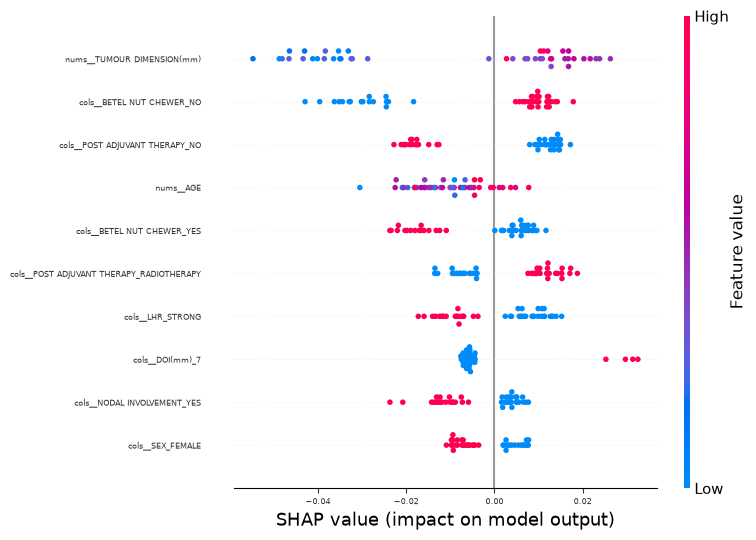

In [23]:
# ==========================================
# 2. SHAP (Model Interpretability)
# ==========================================
import shap
# Initialize the JS visualization code for SHAP (important if running in Jupyter/Colab)
shap.initjs()

# Create the explainer using our trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for the testing set
# Note: Ensure X_test is a Pandas DataFrame with column names intact so the plot reads well
shap_values = explainer.shap_values(X_test_df)

# Generate a Summary Plot with top 10 features and reduced label size
# Remove fig, ax = plt.subplots(...) and ax=ax from shap.summary_plot
shap.summary_plot(shap_values[:, :, 1], X_test_df, max_display=10, show=False) # Use shap_values[:, :, 1] for the positive class

# Get the current axes to adjust the font size
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_fontsize(6)
for label in ax.get_xticklabels():
    label.set_fontsize(6)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

> Interpreting the graph: the higher the feature is in the list the more it affects it right, and points on the left mean it effects the model towards 0 while points on the right means it effects model towards the 1

#Conclusion

The "Early Screening" Philosophy
The entire goal of a screening tool (like a mammogram or a PSA blood test) is to cast a wide net. You want to be highly sensitive to ensure almost nobody with the disease slips through the cracks.

Logistic Regression: Caught 7 out of 8 recurrences (88% Recall). It only sent 1 high-risk patient home.

Random Forest: Caught 5 out of 8 recurrences (62% Recall). It sent 3 high-risk patients home.

If a doctor uses the Random Forest model, nearly 40% of the patients whose cancer is destined to return will be told they are low risk. In oncology, a False Negative (missing a recurrence) is usually considered catastrophic compared to a False Positive.

The Cost of Alarm Fatigue vs. The Cost of Missing Cancer


Alarm fatigue is a massive concern. If a model cries wolf too often, nurses and doctors will start ignoring it.

The Logistic Regression model triggered 19 false alarms, while the Random Forest only triggered 11. But we have to ask: What happens to a patient when the model flags them as "High Risk"?

Does the hospital immediately do an invasive surgery? If yes, then 19 false alarms is unacceptable, and you should use the Random Forest.

Does the hospital simply schedule them for a routine follow-up scan in 3 months instead of 6 months? If yes, the "cost" of a false alarm is just a bit of time and money, which is heavily outweighed by the benefit of catching 2 extra cancer recurrences using the Logistic Regression model.

##To do list

### Streamlit Deployment Requirements
Install these libraries to ensure you have everything needed for a stylized deployment.

In [24]:
!pip install streamlit shap xgboost scikit-learn pandas numpy matplotlib seaborn streamlit-option-menu


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Comprehensive Library Installation List
This list includes every library used in this notebook for data cleaning, visualization, machine learning, SHAP analysis, and Streamlit deployment.

In [25]:
!pip install pandas numpy matplotlib seaborn openpyxl scikit-learn xgboost shap streamlit streamlit-option-menu


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Library Breakdown:**

*   **Data Handling:** `pandas`, `numpy`, `openpyxl` (for Excel files)
*   **Visualization:** `matplotlib`, `seaborn`
*   **Machine Learning:** `scikit-learn`, `xgboost`
*   **Explainability:** `shap`
*   **Deployment:** `streamlit`, `streamlit-option-menu` (for custom navigation)

### Basic Streamlit App Structure with CSS & SHAP
This is a template for how your `app.py` would look to incorporate your model, SHAP, and custom styling.

In [26]:
import streamlit as st
import pandas as pd
import shap
import matplotlib.pyplot as plt
import pickle
import streamlit-option-menu
import xgboost
import scikit-learn
import seaborn
import numpy
import openpyx1

# Custom CSS for styling
st.markdown("""
    <style>
    .main {
        background-color: #f5f5f5;
    }
    .stButton>button {
        width: 100%;
        border-radius: 5px;
        height: 3em;
        background-color: #007bff;
        color: white;
    }
    </style>
    """, unsafe_allow_html=True)

st.title("OSCC Recurrence Prediction Dashboard")

# Sidebar and inputs would go here...

# To display SHAP in Streamlit:
# st.subheader("Feature Importance (SHAP)")
# fig, ax = plt.subplots()
# shap.summary_plot(shap_values, X_test, show=False)
# st.pyplot(fig)

SyntaxError: invalid syntax (2264298203.py, line 6)